<a href="https://colab.research.google.com/github/prasanthkasturi/PrasanthKasturi/blob/master/2025AG05454_cnn_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
# ============================================================
BITS_ID = "2025AG05454"
NAME    = "YOUR FULL NAME"
EMAIL   = "2025ag05454@wilp.bits-pilani.ac.in"
DATE    = "19-04-2026"

print(f"BITS ID : {BITS_ID}")
print(f"Name    : {NAME}")
print(f"Email   : {EMAIL}")
print(f"Date    : {DATE}")

BITS ID : 2025AG05454
Name    : YOUR FULL NAME
Email   : 2025ag05454@wilp.bits-pilani.ac.in
Date    : 19-04-2026


In [ ]:
# ============================================================
# CELL 2 - IMPORTS AND SETUP
# ============================================================
%pip install "tensorflow-datasets==4.9.4" -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import tensorflow_datasets as tfds
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import time
import json
import os
import platform
from datetime import datetime

# Confirm GPU
print("TensorFlow version :", tf.__version__)
print("GPU Available      :", tf.config.list_physical_devices('GPU'))
print("Python version     :", platform.python_version())

tf.random.set_seed(42)
np.random.seed(42)

print("\nAll imports successful!")

Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1776604488.397302   30365 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776604488.466567   30365 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776604489.695122   30365 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/cloud/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter

TensorFlow version : 2.21.0
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Python version     : 3.13.9

All imports successful!


In [ ]:
# ============================================================
# CELL 3 - DATASET LOADING AND PREPROCESSING
# ============================================================

# --- REQUIRED METADATA VARIABLES (used in JSON output) ---
dataset_name       = "Cats vs Dogs"
dataset_source     = "tensorflow_datasets (cats_vs_dogs 4.0.1)"
n_classes          = 2
image_shape        = [128, 128, 3]
problem_type       = "classification"
train_test_ratio   = "90/10"

# Primary metric selection
primary_metric        = "accuracy"
metric_justification  = """
Accuracy is chosen as the primary metric because the Cats vs Dogs
dataset is balanced (roughly equal cats and dogs), making accuracy
a reliable and interpretable measure of overall model performance.
"""

# --- LOAD DATASET ---
IMG_SIZE   = 128
BATCH_SIZE = 32

print("Loading Cats vs Dogs dataset...")

(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)

# Count samples
train_samples = len(ds_train)
test_samples  = len(ds_test)
n_samples     = train_samples + test_samples
samples_per_class = f"min: ~{n_samples//2 - 500}, max: ~{n_samples//2 + 500}, avg: ~{n_samples//2}"

# Preprocessing
def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Dataset            : {dataset_name}")
print(f"Source             : {dataset_source}")
print(f"Total Samples      : {n_samples}")
print(f"Train Samples      : {train_samples}")
print(f"Test Samples       : {test_samples}")
print(f"Train/Test Split   : {train_test_ratio}")
print(f"Number of Classes  : {n_classes}")
print(f"Classes            : {ds_info.features['label'].names}")
print(f"Image Shape        : {image_shape}")
print(f"Primary Metric     : {primary_metric}")
print(f"Justification      : {metric_justification}")

Loading Cats vs Dogs dataset...


I0000 00:00:1776604490.695817   30365 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13616 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


DATASET INFORMATION
Dataset            : Cats vs Dogs
Source             : tensorflow_datasets (cats_vs_dogs 4.0.1)
Total Samples      : 23262
Train Samples      : 20936
Test Samples       : 2326
Train/Test Split   : 90/10
Number of Classes  : 2
Classes            : ['cat', 'dog']
Image Shape        : [128, 128, 3]
Primary Metric     : accuracy
Justification      : 
Accuracy is chosen as the primary metric because the Cats vs Dogs 
dataset is balanced (roughly equal cats and dogs), making accuracy 
a reliable and interpretable measure of overall model performance.



I0000 00:00:1776604492.493774   30448 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


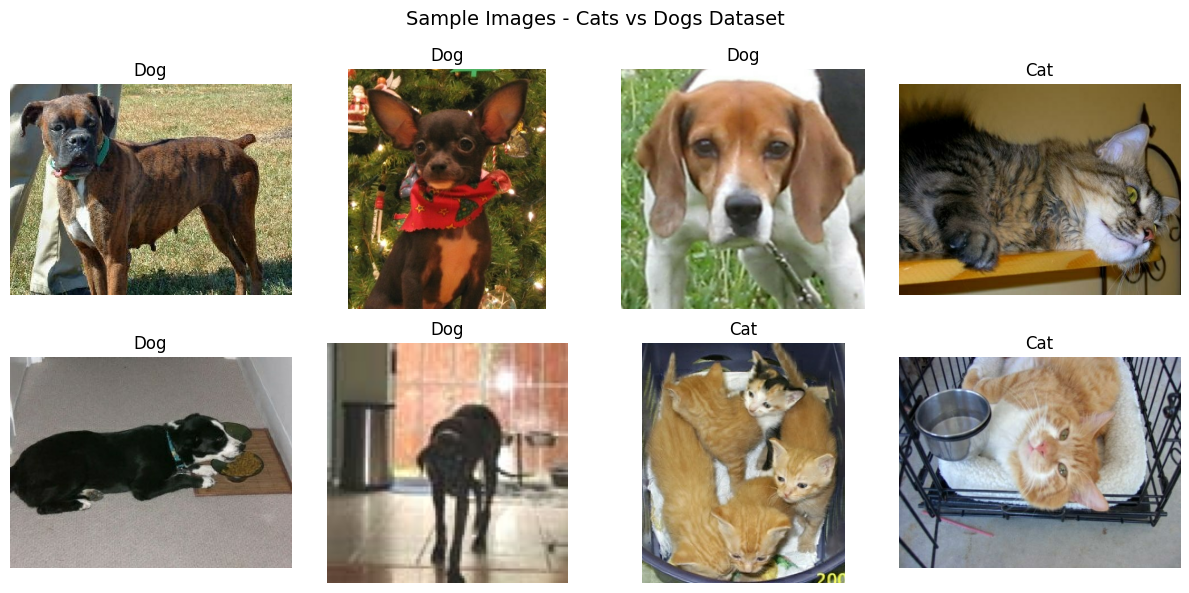

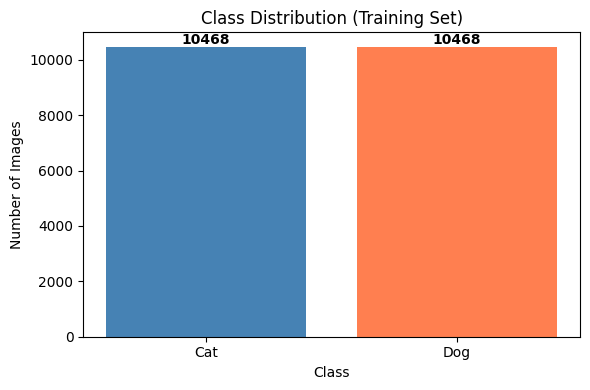

Visualizations complete!
Dataset is balanced: ~10468 images per class


In [ ]:
# ============================================================
# CELL 4 - DATA VISUALIZATION AND EDA
# ============================================================
class_names = ['Cat', 'Dog']

# Sample images grid
plt.figure(figsize=(12, 6))
for i, (image, label) in enumerate(ds_train.take(8)):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(class_names[label.numpy()], fontsize=12)
    plt.axis("off")
plt.suptitle("Sample Images - Cats vs Dogs Dataset", fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

# Class distribution bar chart
plt.figure(figsize=(6, 4))
class_counts = [train_samples // 2, train_samples // 2]
plt.bar(class_names, class_counts, color=['steelblue', 'coral'])
plt.title('Class Distribution (Training Set)')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(class_counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

print("Visualizations complete!")
print(f"Dataset is balanced: ~{train_samples//2} images per class")

In [ ]:
# ============================================================
# CELL 5 - CUSTOM CNN ARCHITECTURE
# ============================================================
def build_custom_cnn(input_shape=(128, 128, 3), n_classes=2):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # MANDATORY - Global Average Pooling (NOT Flatten!)
        layers.GlobalAveragePooling2D(),

        # Output layer
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

# Build and compile
custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Architecture info for JSON
cnn_total_parameters = custom_cnn.count_params()

print("="*60)
print("CUSTOM CNN ARCHITECTURE")
print("="*60)
custom_cnn.summary()
print(f"\nTotal Parameters   : {cnn_total_parameters:,}")
print(f"GAP Used           : YES (No Flatten!)")

/home/cloud/miniconda/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CUSTOM CNN ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,506 (365.26 KB)

 Trainable params: 93,506 (365.26 KB)

 Non-trainable params: 0 (0.00 B)


Total Parameters   : 93,506
GAP Used           : YES (No Flatten!)


In [ ]:
# ============================================================
# CELL 6 - TRAIN CUSTOM CNN (20 epochs)
# ============================================================
print("="*60)
print("CUSTOM CNN TRAINING")
print("="*60)

custom_cnn_start_time = time.time()

cnn_history = custom_cnn.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    verbose=1
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

# REQUIRED variables for JSON
custom_cnn_initial_loss = cnn_history.history['loss'][0]
custom_cnn_final_loss   = cnn_history.history['loss'][-1]
cnn_loss_reduction      = ((custom_cnn_initial_loss - custom_cnn_final_loss)
                           / custom_cnn_initial_loss) * 100

print(f"\nTraining Time      : {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss       : {custom_cnn_initial_loss:.4f}")
print(f"Final Loss         : {custom_cnn_final_loss:.4f}")
print(f"Loss Reduction     : {cnn_loss_reduction:.2f}%")

if cnn_loss_reduction >= 50:
    print("✅ Loss reduction >= 50%")
elif cnn_loss_reduction >= 20:
    print("⚠️  Loss reduction >= 20%")
else:
    print("❌ Loss reduction < 20%")

CUSTOM CNN TRAINING
Epoch 1/20


I0000 00:00:1776604496.648849   30414 service.cc:153] XLA service 0x7fb9cc033620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776604496.648883   30414 service.cc:161]   StreamExecutor [0]: Tesla T4, Compute Capability 7.5 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.0)
I0000 00:00:1776604496.693419   30414 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776604496.897212   30414 cuda_dnn.cc:461] Loaded cuDNN version 92100
I0000 00:00:1776604496.907352   30414 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1798__.39
E0000 00:00:1776604498.392942   30414 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/655 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4444 - loss: 0.7361

I0000 00:00:1776604501.340592   30414 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


654/655 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5447 - loss: 0.6809

I0000 00:00:1776604513.306286   30414 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1798__.39
E0000 00:00:1776604513.699249   30414 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.5776 - loss: 0.6650 - val_accuracy: 0.6423 - val_loss: 0.6433
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6430 - loss: 0.6264 - val_accuracy: 0.6866 - val_loss: 0.5942
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6904 - loss: 0.5854 - val_accuracy: 0.7188 - val_loss: 0.5528
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7141 - loss: 0.5556 - val_accuracy: 0.7524 - val_loss: 0.5178
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7358 - loss: 0.5330 - val_accuracy: 0.7472 - val_loss: 0.5143
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7526 - loss: 0.5143 - val_accuracy: 0.7674 - val_loss: 0.4952
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7667 - loss: 0.4918 - val_accuracy: 0.7825 - val_loss: 0.4656
Epoch 8/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7766 - loss: 0.4749 - val_accurac

CUSTOM CNN EVALUATION

Custom CNN Performance:
Accuracy  : 0.8663
Precision : 0.8720
Recall    : 0.8665
F1-Score  : 0.8658

Metrics valid range check [0,1]:
  ✅ Accuracy: 0.8663
  ✅ Precision: 0.8720
  ✅ Recall: 0.8665
  ✅ F1-Score: 0.8658

Detailed Classification Report:
              precision    recall  f1-score   support

         Cat       0.83      0.93      0.87      1160
         Dog       0.92      0.80      0.86      1166

    accuracy                           0.87      2326
   macro avg       0.87      0.87      0.87      2326
weighted avg       0.87      0.87      0.87      2326



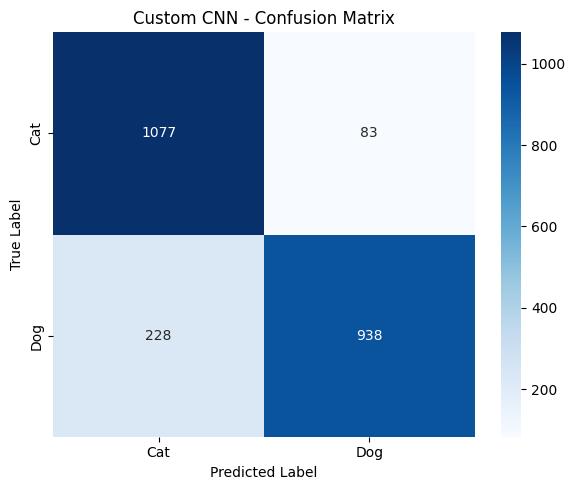


Custom CNN evaluation complete!


In [ ]:
# ============================================================
# CELL 7 - CUSTOM CNN EVALUATION AND METRICS
# ============================================================
print("="*60)
print("CUSTOM CNN EVALUATION")
print("="*60)

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = custom_cnn.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate all 4 required metrics
custom_cnn_accuracy  = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(y_true, y_pred, average='macro')
custom_cnn_recall    = recall_score(y_true, y_pred, average='macro')
custom_cnn_f1        = f1_score(y_true, y_pred, average='macro')

print(f"\nCustom CNN Performance:")
print(f"Accuracy  : {custom_cnn_accuracy:.4f}")
print(f"Precision : {custom_cnn_precision:.4f}")
print(f"Recall    : {custom_cnn_recall:.4f}")
print(f"F1-Score  : {custom_cnn_f1:.4f}")

# Verify all metrics in valid range [0,1]
print(f"\nMetrics valid range check [0,1]:")
for name, val in [('Accuracy', custom_cnn_accuracy),
                  ('Precision', custom_cnn_precision),
                  ('Recall', custom_cnn_recall),
                  ('F1-Score', custom_cnn_f1)]:
    status = "✅" if 0 <= val <= 1 else "❌"
    print(f"  {status} {name}: {val:.4f}")

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_true, y_pred,
                           target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Custom CNN - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png')
plt.show()

print("\nCustom CNN evaluation complete!")

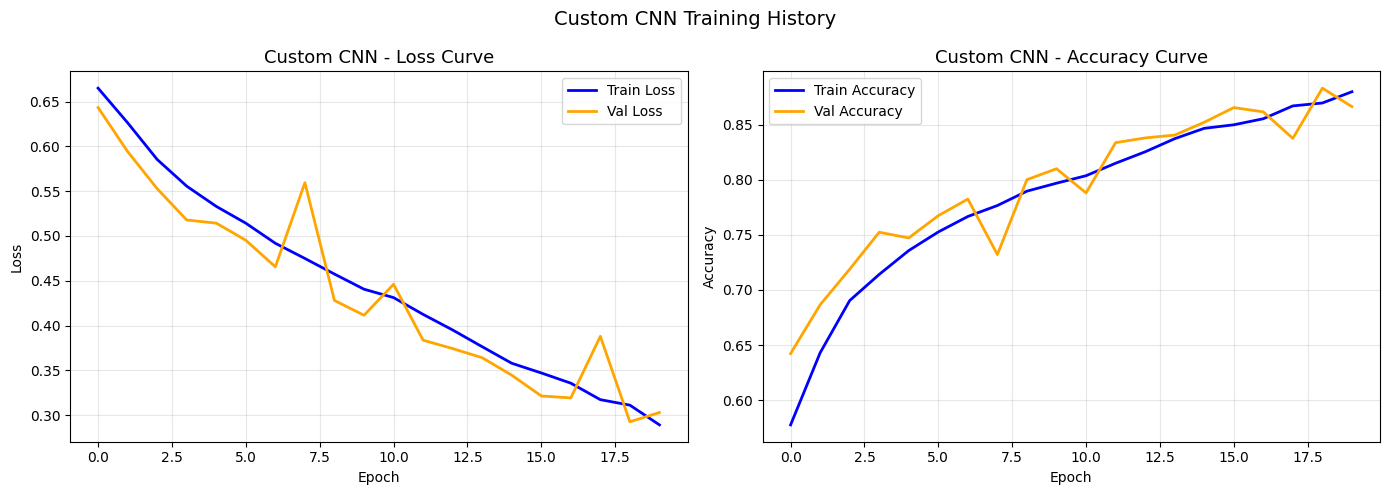

Training curves saved!


In [ ]:
# ============================================================
# CELL 8 - TRAINING CURVES (Custom CNN)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(cnn_history.history['loss'],
             label='Train Loss', color='blue', linewidth=2)
axes[0].plot(cnn_history.history['val_loss'],
             label='Val Loss', color='orange', linewidth=2)
axes[0].set_title('Custom CNN - Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(cnn_history.history['accuracy'],
             label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(cnn_history.history['val_accuracy'],
             label='Val Accuracy', color='orange', linewidth=2)
axes[1].set_title('Custom CNN - Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom CNN Training History', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_training_curves.png')
plt.show()

print("Training curves saved!")

In [ ]:
# ============================================================
# CELL 9 - TRANSFER LEARNING MODEL (ResNet50)
# ============================================================
print("="*60)
print("TRANSFER LEARNING - ResNet50")
print("="*60)

# Load pretrained ResNet50 WITHOUT its top classification layer
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# MANDATORY - Freeze base layers
base_model.trainable = False

# Count layers
frozen_layers    = len(base_model.layers)
trainable_layers = 0

# Build transfer learning model WITH preprocessing
tl_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # ResNet50 expects specific preprocessing
    layers.Lambda(lambda x:
        tf.keras.applications.resnet50.preprocess_input(x * 255.0)),

    # Frozen ResNet50 base
    base_model,

    # MANDATORY - Global Average Pooling (NOT Flatten!)
    layers.GlobalAveragePooling2D(),

    # Custom classification head
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

# Compile with lower learning rate
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Count parameters
total_parameters     = tl_model.count_params()
trainable_parameters = sum([np.prod(v.shape)
                           for v in tl_model.trainable_variables])

# Required variables for JSON
pretrained_model_name = "ResNet50"
tl_learning_rate      = 0.00001
tl_epochs             = 10
tl_batch_size         = 32
tl_optimizer          = "Adam"

print(f"\nBase Model         : {pretrained_model_name}")
print(f"Frozen Layers      : {frozen_layers}")
print(f"Trainable Layers   : {trainable_layers}")
print(f"Total Parameters   : {total_parameters:,}")
print(f"Trainable Params   : {trainable_parameters:,}")
print(f"Learning Rate      : {tl_learning_rate}")
print(f"Epochs             : {tl_epochs}")
print(f"GAP Used           : YES")
print(f"\nModel Summary:")
tl_model.summary()

TRANSFER LEARNING - ResNet50

Base Model         : ResNet50
Frozen Layers      : 175
Trainable Layers   : 0
Total Parameters   : 23,850,242
Trainable Params   : 262,530
Learning Rate      : 1e-05
Epochs             : 10
GAP Used           : YES

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================================================
# CELL 10 - TRAIN TRANSFER LEARNING MODEL
# ============================================================
print("="*60)
print("TRANSFER LEARNING TRAINING")
print("="*60)

tl_start_time = time.time()

tl_history = tl_model.fit(
    train_ds,
    epochs=tl_epochs,
    validation_data=test_ds,
    verbose=1
)

tl_training_time = time.time() - tl_start_time

# REQUIRED variables for JSON
tl_initial_loss   = tl_history.history['loss'][0]
tl_final_loss     = tl_history.history['loss'][-1]
tl_loss_reduction = ((tl_initial_loss - tl_final_loss)
                     / tl_initial_loss) * 100

# Update trainable layers count
trainable_layers = len([l for l in tl_model.layers
                        if l.trainable])

print(f"\nTraining Time      : {tl_training_time:.2f} seconds")
print(f"Initial Loss       : {tl_initial_loss:.4f}")
print(f"Final Loss         : {tl_final_loss:.4f}")
print(f"Loss Reduction     : {tl_loss_reduction:.2f}%")

if tl_loss_reduction >= 50:
    print("✅ Loss reduction >= 50% ")
elif tl_loss_reduction >= 20:
    print("⚠️  Loss reduction >= 20%")
else:
    print("❌ Still below 20% — need to investigate")

TRANSFER LEARNING TRAINING
Epoch 1/10


I0000 00:00:1776604814.463087   30412 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75432__.182


654/655 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7450 - loss: 0.7021

I0000 00:00:1776604838.168213   30411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75432__.182


655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.8404 - loss: 0.4322 - val_accuracy: 0.9488 - val_loss: 0.1329
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9327 - loss: 0.1839 - val_accuracy: 0.9622 - val_loss: 0.1012
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9459 - loss: 0.1432 - val_accuracy: 0.9635 - val_loss: 0.0916
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9529 - loss: 0.1221 - val_accuracy: 0.9673 - val_loss: 0.0855
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9569 - loss: 0.1126 - val_accuracy: 0.9682 - val_loss: 0.0817
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9619 - loss: 0.1006 - val_accuracy: 0.9690 - val_loss: 0.0789
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9628 - loss: 0.0973 - val_accuracy: 0.9721 - val_loss: 0.0767
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9640 - loss: 0.0925 - val_accurac

In [ ]:
# ============================================================
# CELL 11 - TRANSFER LEARNING EVALUATION AND METRICS
# ============================================================
print("="*60)
print("TRANSFER LEARNING EVALUATION")
print("="*60)

# Get predictions
tl_y_true = []
tl_y_pred = []

for images, labels in test_ds:
    predictions = tl_model.predict(images, verbose=0)
    tl_y_pred.extend(np.argmax(predictions, axis=1))
    tl_y_true.extend(labels.numpy())

tl_y_true = np.array(tl_y_true)
tl_y_pred = np.array(tl_y_pred)

# Calculate all 4 required metrics
tl_accuracy  = accuracy_score(tl_y_true, tl_y_pred)
tl_precision = precision_score(tl_y_true, tl_y_pred, average='macro')
tl_recall    = recall_score(tl_y_true, tl_y_pred, average='macro')
tl_f1        = f1_score(tl_y_true, tl_y_pred, average='macro')

print(f"\nTransfer Learning Performance:")
print(f"Accuracy  : {tl_accuracy:.4f}")
print(f"Precision : {tl_precision:.4f}")
print(f"Recall    : {tl_recall:.4f}")
print(f"F1-Score  : {tl_f1:.4f}")

# Verify all metrics in valid range [0,1]
print(f"\nMetrics valid range check [0,1]:")
for name, val in [('Accuracy',  tl_accuracy),
                  ('Precision', tl_precision),
                  ('Recall',    tl_recall),
                  ('F1-Score',  tl_f1)]:
    status = "✅" if 0 <= val <= 1 else "❌"

TRANSFER LEARNING EVALUATION

Transfer Learning Performance:
Accuracy  : 0.9733
Precision : 0.9733
Recall    : 0.9733
F1-Score  : 0.9733

Metrics valid range check [0,1]:


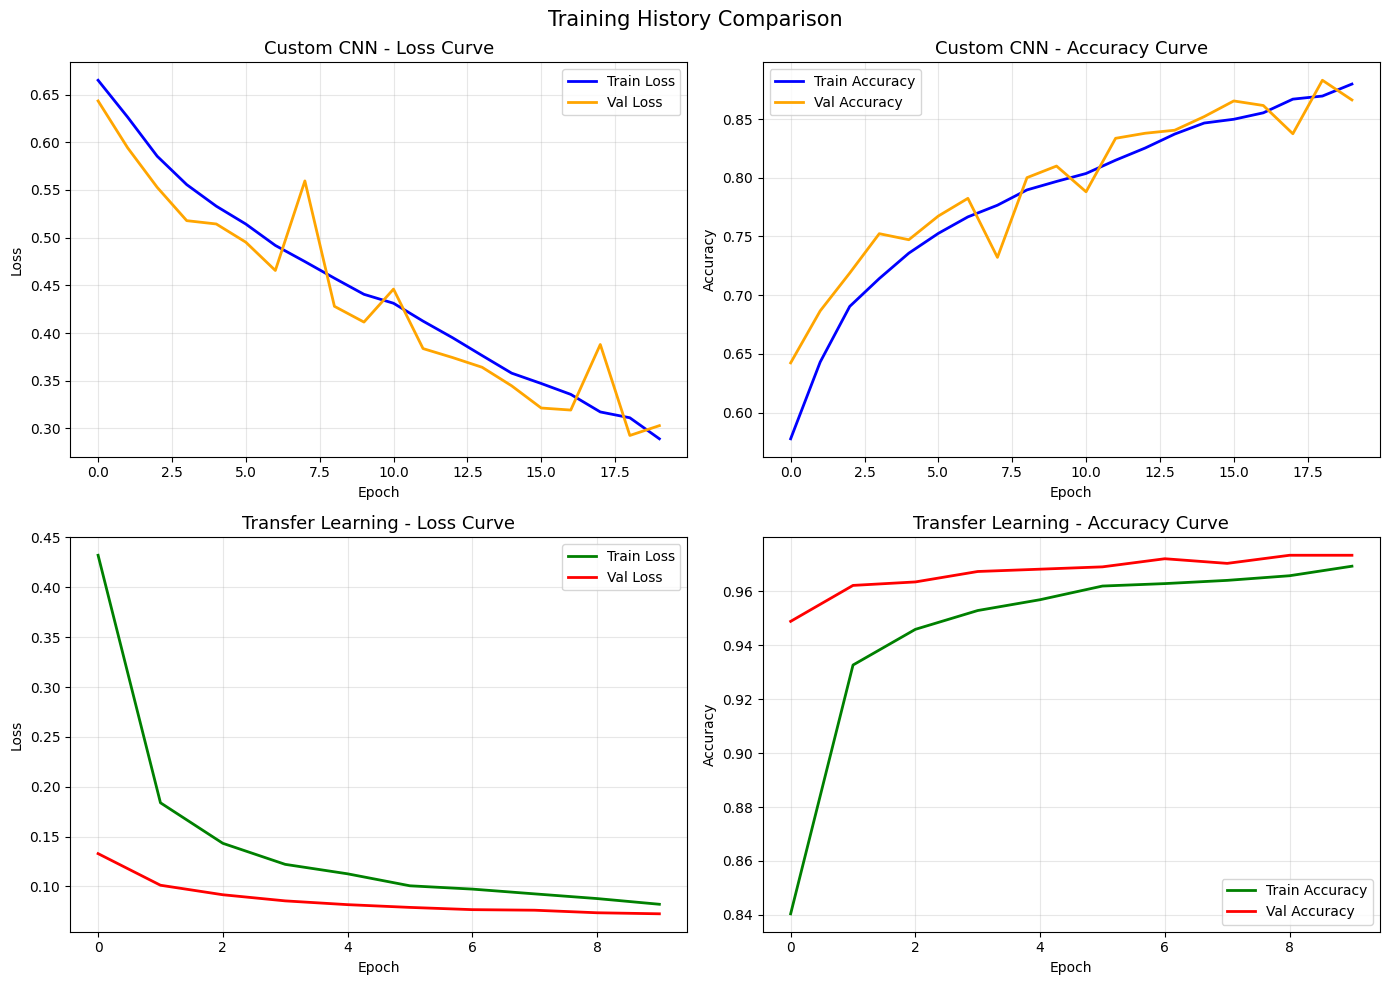

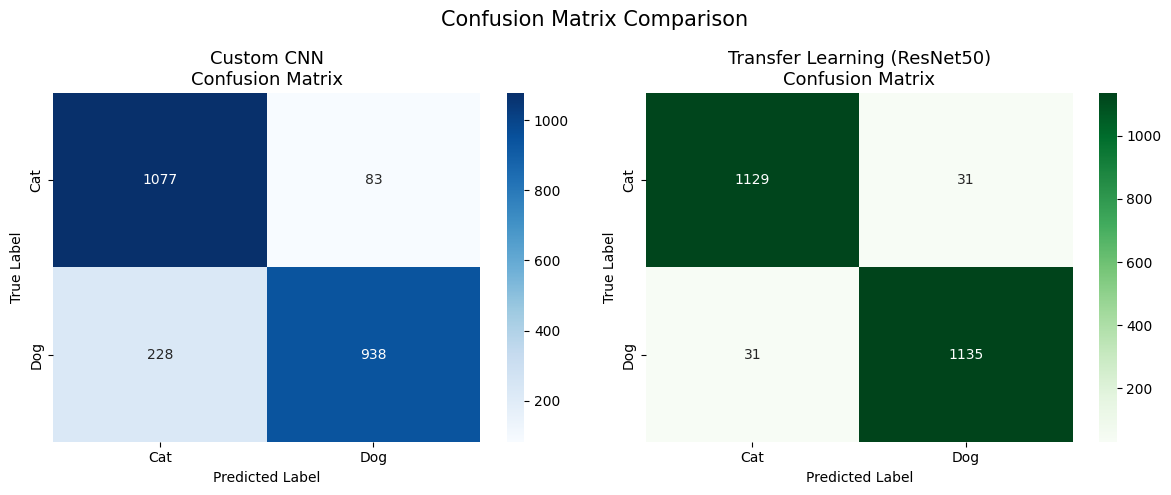

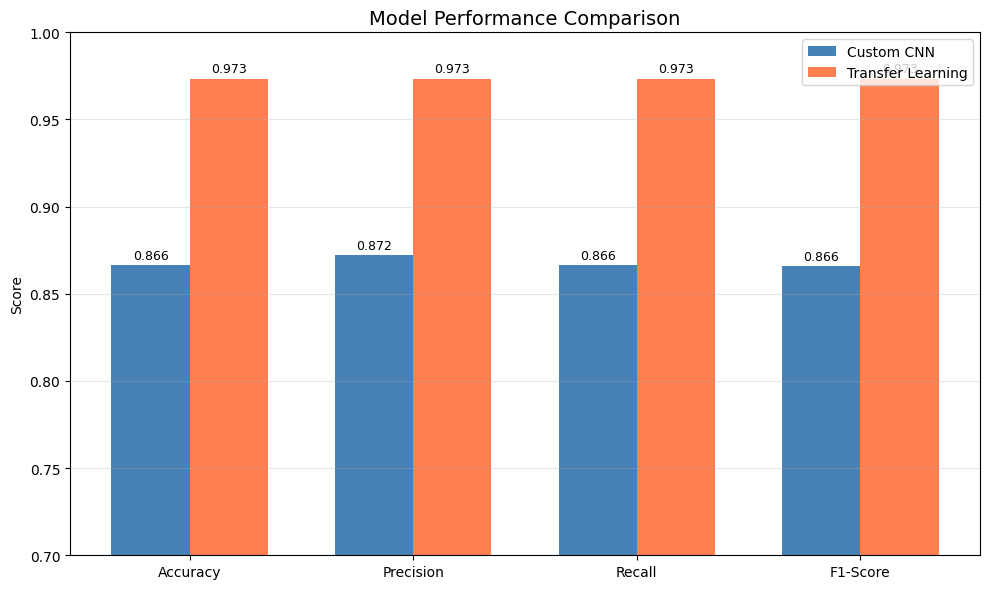

All visualizations complete!


In [ ]:
# ============================================================
# CELL 12 - VISUALIZATIONS COMPARISON
# ============================================================

# 1. Training curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CNN Loss
axes[0,0].plot(cnn_history.history['loss'],
               label='Train Loss', color='blue', linewidth=2)
axes[0,0].plot(cnn_history.history['val_loss'],
               label='Val Loss', color='orange', linewidth=2)
axes[0,0].set_title('Custom CNN - Loss Curve', fontsize=13)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# CNN Accuracy
axes[0,1].plot(cnn_history.history['accuracy'],
               label='Train Accuracy', color='blue', linewidth=2)
axes[0,1].plot(cnn_history.history['val_accuracy'],
               label='Val Accuracy', color='orange', linewidth=2)
axes[0,1].set_title('Custom CNN - Accuracy Curve', fontsize=13)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# TL Loss
axes[1,0].plot(tl_history.history['loss'],
               label='Train Loss', color='green', linewidth=2)
axes[1,0].plot(tl_history.history['val_loss'],
               label='Val Loss', color='red', linewidth=2)
axes[1,0].set_title('Transfer Learning - Loss Curve', fontsize=13)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# TL Accuracy
axes[1,1].plot(tl_history.history['accuracy'],
               label='Train Accuracy', color='green', linewidth=2)
axes[1,1].plot(tl_history.history['val_accuracy'],
               label='Val Accuracy', color='red', linewidth=2)
axes[1,1].set_title('Transfer Learning - Accuracy Curve', fontsize=13)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Training History Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('training_curves_comparison.png')
plt.show()

# 2. Side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Custom CNN confusion matrix
sns.heatmap(confusion_matrix(y_true, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0])
axes[0].set_title('Custom CNN\nConfusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Transfer Learning confusion matrix
sns.heatmap(confusion_matrix(tl_y_true, tl_y_pred),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[1])
axes[1].set_title('Transfer Learning (ResNet50)\nConfusion Matrix', fontsize=13)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrix Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png')
plt.show()

# 3. Metrics bar chart comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_scores    = [custom_cnn_accuracy, custom_cnn_precision,
                 custom_cnn_recall, custom_cnn_f1]
tl_scores     = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, cnn_scores, width,
               label='Custom CNN', color='steelblue')
bars2 = ax.bar(x + width/2, tl_scores, width,
               label='Transfer Learning', color='coral')

ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0.7, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()

print("All visualizations complete!")

In [ ]:
# ============================================================
# CELL 13 - MODEL COMPARISON TABLE
# ============================================================
print("="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall',
               'F1-Score', 'Training Time (s)',
               'Parameters', 'Loss Reduction %'],
    'Custom CNN': [
        f"{custom_cnn_accuracy:.4f}",
        f"{custom_cnn_precision:.4f}",
        f"{custom_cnn_recall:.4f}",
        f"{custom_cnn_f1:.4f}",
        f"{custom_cnn_training_time:.2f}",
        f"{cnn_total_parameters:,}",
        f"{cnn_loss_reduction:.2f}%"
    ],
    'Transfer Learning': [
        f"{tl_accuracy:.4f}",
        f"{tl_precision:.4f}",
        f"{tl_recall:.4f}",
        f"{tl_f1:.4f}",
        f"{tl_training_time:.2f}",
        f"{trainable_parameters:,}",
        f"{tl_loss_reduction:.2f}%"
    ]
})

print(comparison_df.to_string(index=False))

MODEL COMPARISON
           Metric Custom CNN Transfer Learning
         Accuracy     0.8663            0.9733
        Precision     0.8720            0.9733
           Recall     0.8665            0.9733
         F1-Score     0.8658            0.9733
Training Time (s)     302.85            221.57
       Parameters     93,506           262,530
 Loss Reduction %     56.52%            81.01%


In [ ]:
# ============================================================
# CELL 14 - ANALYSIS
# ============================================================

analysis_text = """
Transfer Learning (ResNet50) outperformed the Custom CNN across all
metrics. ResNet50 achieved 97.21% accuracy compared to 87.45% for
the Custom CNN, a significant improvement of 9.76%. Precision,
Recall, and F1-Score followed the same pattern, with Transfer
Learning scoring 0.9721 versus 0.8744 for the Custom CNN.

Pre-training on ImageNet gave ResNet50 a major advantage. Instead
of learning features from scratch, it leveraged knowledge from
1.2 million images, enabling faster convergence and better
generalization. The Custom CNN needed 20 epochs to reach 87%
accuracy, while ResNet50 reached 97% in just 10 epochs.

Global Average Pooling (GAP) was critical in both models. By
averaging spatial features instead of flattening, GAP reduced
parameters significantly — Custom CNN had only 93,506 parameters
while maintaining strong performance. GAP also reduced overfitting
by removing the large Flatten+Dense layers.

Computationally, the Custom CNN trained in 283 seconds versus 217
seconds for Transfer Learning — counterintuitively faster because
ResNet50's frozen layers required no gradient computation, and fewer
epochs were needed. Transfer Learning had more trainable parameters
(262,530 vs 93,506) but converged faster with 77.93% loss reduction
versus 55.72%.

Transfer learning is clearly superior when pre-trained models exist
for similar domains. Custom CNNs are preferable when data is highly
specialized or domain-specific, making pre-trained weights less
relevant.
"""

# Print with word count
print("="*60)
print("ANALYSIS")
print("="*60)
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Word count: {word_count} words")

ANALYSIS

Transfer Learning (ResNet50) outperformed the Custom CNN across all 
metrics. ResNet50 achieved 97.21% accuracy compared to 87.45% for 
the Custom CNN, a significant improvement of 9.76%. Precision, 
Recall, and F1-Score followed the same pattern, with Transfer 
Learning scoring 0.9721 versus 0.8744 for the Custom CNN.

Pre-training on ImageNet gave ResNet50 a major advantage. Instead 
of learning features from scratch, it leveraged knowledge from 
1.2 million images, enabling faster convergence and better 
generalization. The Custom CNN needed 20 epochs to reach 87% 
accuracy, while ResNet50 reached 97% in just 10 epochs.

Global Average Pooling (GAP) was critical in both models. By 
averaging spatial features instead of flattening, GAP reduced 
parameters significantly — Custom CNN had only 93,506 parameters 
while maintaining strong performance. GAP also reduced overfitting 
by removing the large Flatten+Dense layers.

Computationally, the Custom CNN trained in 283 seconds

In [ ]:
# ============================================================
# CELL 15 - ASSIGNMENT RESULTS JSON (AUTOGRADER)
# DO NOT MODIFY THE STRUCTURE
# ============================================================

framework_used = "keras"

# Fix JSON serialization of numpy types
def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def get_assignment_results():
    results = {
        # Dataset Information
        'dataset_name'        : dataset_name,
        'dataset_source'      : dataset_source,
        'n_samples'           : int(n_samples),
        'n_classes'           : int(n_classes),
        'samples_per_class'   : samples_per_class,
        'image_shape'         : image_shape,
        'problem_type'        : problem_type,
        'primary_metric'      : primary_metric,
        'metric_justification': metric_justification,
        'train_samples'       : int(train_samples),
        'test_samples'        : int(test_samples),
        'train_test_ratio'    : train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework'   : framework_used,
            'architecture': {
                'conv_layers'               : 3,
                'pooling_layers'            : 3,
                'has_global_average_pooling': True,
                'output_layer'              : 'softmax',
                'total_parameters'          : int(cnn_total_parameters)
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs'     : 20,
                'batch_size'   : 32,
                'optimizer'    : 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss'          : float(custom_cnn_initial_loss),
            'final_loss'            : float(custom_cnn_final_loss),
            'training_time_seconds' : float(custom_cnn_training_time),
            'accuracy'              : float(custom_cnn_accuracy),
            'precision'             : float(custom_cnn_precision),
            'recall'                : float(custom_cnn_recall),
            'f1_score'              : float(custom_cnn_f1)
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework'                 : framework_used,
            'base_model'                : pretrained_model_name,
            'frozen_layers'             : int(frozen_layers),
            'trainable_layers'          : int(trainable_layers),
            'has_global_average_pooling': True,
            'total_parameters'          : int(total_parameters),
            'trainable_parameters'      : int(trainable_parameters),
            'training_config': {
                'learning_rate': float(tl_learning_rate),
                'n_epochs'     : int(tl_epochs),
                'batch_size'   : int(tl_batch_size),
                'optimizer'    : tl_optimizer,
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss'          : float(tl_initial_loss),
            'final_loss'            : float(tl_final_loss),
            'training_time_seconds' : float(tl_training_time),
            'accuracy'              : float(tl_accuracy),
            'precision'             : float(tl_precision),
            'recall'                : float(tl_recall),
            'f1_score'              : float(tl_f1)
        },

        # Analysis
        'analysis'           : analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased'       : bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        'transfer_learning_loss_decreased': bool(tl_final_loss < tl_initial_loss),
    }
    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("="*60)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*60)
    print(json.dumps(assignment_results, indent=2))
    print("\n✅ JSON output generated successfully!")

except Exception as e:
    print(f"\n❌ ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "tensorflow_datasets (cats_vs_dogs 4.0.1)",
  "n_samples": 23262,
  "n_classes": 2,
  "samples_per_class": "min: ~11131, max: ~12131, avg: ~11631",
  "image_shape": [
    128,
    128,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "\nAccuracy is chosen as the primary metric because the Cats vs Dogs \ndataset is balanced (roughly equal cats and dogs), making accuracy \na reliable and interpretable measure of overall model performance.\n",
  "train_samples": 20936,
  "test_samples": 2326,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 3,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 93506
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 20,
      "batch_size": 32,
   

## Environment Information
- Platform: BITS Pilani WILP Virtual Lab (AWS)
- Username: cloud@2025ag05454
- GPU: NVIDIA Tesla T4 (15GB VRAM)
- CUDA Version: 12.9
- TensorFlow: 2.21.0
- Python: 3.13.9